   LOSO RESULTS SUMMARY: T6_noPT_uniform

[Mean per-user weighted F1]
 → 0.6968161230678267

[All data weighted F1]
 → 0.639814190210586

[Per-user detail]
  1: 0.5497
  13: 0.5976
  16: 0.6906
  2: 0.6617
  21: 0.5184
  23: 0.8399
  27: 0.7186
  36: 0.8288
  6: 0.8713
  9: 0.6916


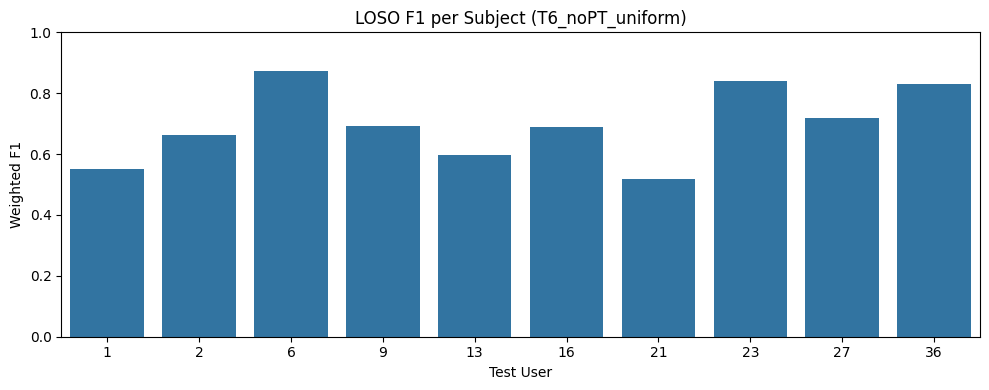

In [2]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# === 読み込み対象ディレクトリ ===
results_dir = "results_loso/T6_noPT_uniform"

# === ファイル一覧 ===
files = sorted(os.listdir(results_dir))

# === 結果格納 ===
f1_per_user = {}
all_y = []
all_p = []

# === 各ファイルの読み込み ===
for fname in files:
    if not fname.endswith(".json"):
        continue

    path = os.path.join(results_dir, fname)
    with open(path, "r") as fp:
        res = json.load(fp)

    user = res["user"]
    y_true = np.array(res["y_true"])
    y_pred = np.array(res["y_pred"])

    # weighted F1
    f1_u = f1_score(y_true, y_pred, average="weighted")
    f1_per_user[user] = f1_u

    # 全体評価用
    all_y.extend(y_true)
    all_p.extend(y_pred)

# === 全体 weighted F1 ===
all_y = np.array(all_y)
all_p = np.array(all_p)
f1_all_weighted = f1_score(all_y, all_p, average="weighted")

# ==== 出力 ====
print("============================================")
print("   LOSO RESULTS SUMMARY: T6_noPT_uniform")
print("============================================")
print("\n[Mean per-user weighted F1]")
print(" →", np.mean(list(f1_per_user.values())))

print("\n[All data weighted F1]")
print(" →", f1_all_weighted)

print("\n[Per-user detail]")
for u, score in f1_per_user.items():
    print(f"  {u}: {score:.4f}")

# ==== プロット ====
plt.figure(figsize=(10, 4))
sns.barplot(x=list(f1_per_user.keys()), y=list(f1_per_user.values()))
plt.ylim(0, 1)
plt.xlabel("Test User")
plt.ylabel("Weighted F1")
plt.title("LOSO F1 per Subject (T6_noPT_uniform)")
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
from scipy.stats import mode

def smooth_majority(y, k=5):
    half = k // 2
    y_smooth = np.copy(y)

    for i in range(len(y)):
        l = max(0, i - half)
        r = min(len(y), i + half + 1)
        y_smooth[i] = mode(y[l:r], keepdims=False).mode

    return y_smooth


    User    F1_raw  F1_smooth
0      1  0.549687   0.534454
1     13  0.597597   0.821233
2     16  0.690603   0.882225
3      2  0.661669   0.845190
4     21  0.518428   0.436881
5     23  0.839883   0.967102
6     27  0.718612   0.890511
7     36  0.828753   0.949763
8      6  0.871332   0.909725
9      9  0.691598   0.776582
10  Mean  0.696816   0.801367


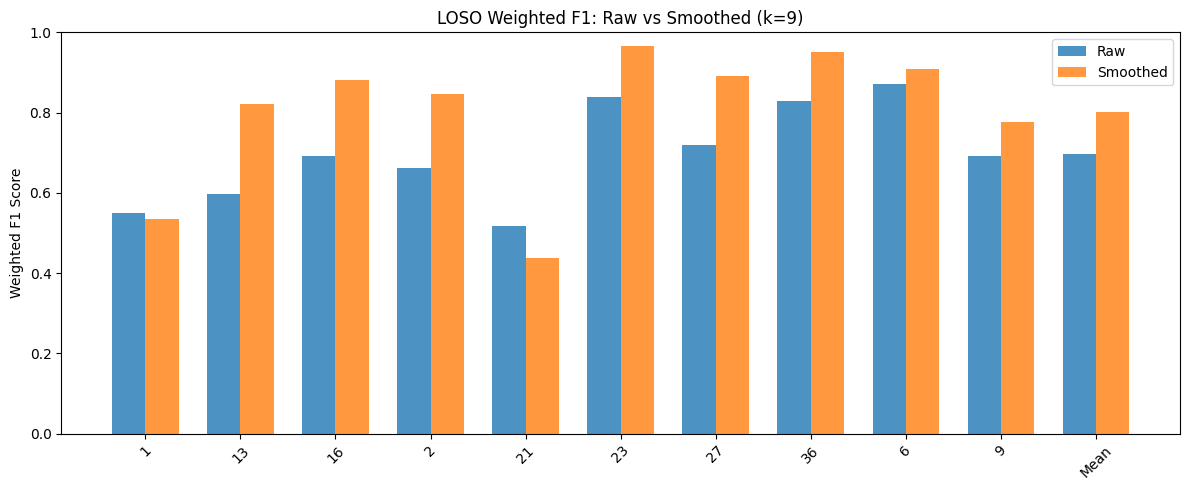

In [10]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=9):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1

    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)   # +1 because slice is exclusive
        segment = y[l:r]

        out[i] = np.bincount(segment).argmax()

    return out

# ==== 結果ディレクトリ ====
results_dir = "results_loso/T6_noPT_uniform"
files = sorted(os.listdir(results_dir))

rows = []

for fname in files:
    if not fname.endswith(".json"):
        continue

    with open(os.path.join(results_dir, fname)) as fp:
        res = json.load(fp)

    user = res["user"]
    y_true = np.array(res["y_true"])
    y_pred = np.array(res["y_pred"])

    # 平滑化
    y_pred_smooth = smooth_majority(y_pred, k=20)

    # F1 計算
    f1_raw = f1_score(y_true, y_pred, average="weighted")
    f1_smooth = f1_score(y_true, y_pred_smooth, average="weighted")

    rows.append([user, f1_raw, f1_smooth])

# ==== DataFrame ====
df = pd.DataFrame(rows, columns=["User", "F1_raw", "F1_smooth"])

# ==== 平均行 ====
df.loc[len(df)] = ["Mean", df["F1_raw"].mean(), df["F1_smooth"].mean()]

print(df)

# ======================================
#           📊 プロット部分
# ======================================
plt.figure(figsize=(12, 5))

x = np.arange(len(df["User"]))
width = 0.35

plt.bar(x - width/2, df["F1_raw"], width=width, label="Raw", alpha=0.8)
plt.bar(x + width/2, df["F1_smooth"], width=width, label="Smoothed", alpha=0.8)

plt.xticks(x, df["User"], rotation=45)
plt.ylim(0, 1)
plt.ylabel("Weighted F1 Score")
plt.title("LOSO Weighted F1: Raw vs Smoothed (k=9)")
plt.legend()

plt.tight_layout()
plt.show()


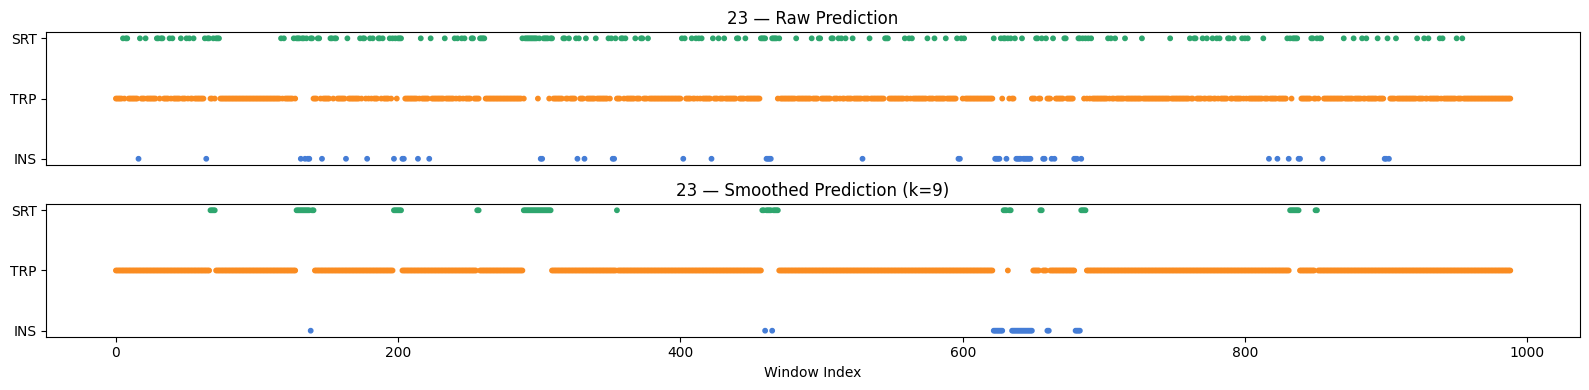

In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ==== smoothing ====
def smooth_majority(y, k=9):
    half = k // 2
    out = y.copy()
    for i in range(len(y)):
        l = max(0, i-half)
        r = min(len(y), i+half+1)
        out[i] = np.bincount(y[l:r]).argmax()
    return out


# ==== 対象ユーザ ====
target_user = "23"
results_dir = "results_loso/T6_noPT_uniform"

# ==== 読み込み ====
with open(os.path.join(results_dir, f"{target_user}.json")) as fp:
    res = json.load(fp)

y_true = np.array(res["y_true"])
y_pred = np.array(res["y_pred"])
y_pred_smooth = smooth_majority(y_pred, k=9)

# ==== INS / TRP / SRT の色設定 ====
color_map = {
    0: (0.27, 0.49, 0.84),   # INS - blue
    1: (0.98, 0.55, 0.13),   # TRP - orange
    2: (0.18, 0.65, 0.43),   # SRT - green
}

colors_raw = [color_map[c] for c in y_pred]
colors_smooth = [color_map[c] for c in y_pred_smooth]

# ==== Plot ====
plt.figure(figsize=(16, 4))

# ---- Raw ----
plt.subplot(2,1,1)
plt.scatter(
    np.arange(len(y_pred)),
    y_pred,
    c=colors_raw,
    s=10
)
plt.title(f"{target_user} — Raw Prediction")
plt.yticks([0,1,2], ["INS", "TRP", "SRT"])
plt.xticks([])

# ---- Smoothed ----
plt.subplot(2,1,2)
plt.scatter(
    np.arange(len(y_pred_smooth)),
    y_pred_smooth,
    c=colors_smooth,
    s=10
)
plt.title(f"{target_user} — Smoothed Prediction (k=9)")
plt.yticks([0,1,2], ["INS", "TRP", "SRT"])
plt.xlabel("Window Index")

plt.tight_layout()
plt.show()


Mean duration (true): {np.int64(1): np.float64(688.0), np.int64(2): np.float64(68.0), np.int64(0): np.float64(396.0)}
Mean duration (raw): {np.int64(1): np.float64(15.555555555555555), np.int64(0): np.float64(18.97142857142857), np.int64(2): np.float64(6.339622641509434)}
Mean duration (smooth): {np.int64(1): np.float64(120.44444444444444), np.int64(0): np.float64(113.33333333333333), np.int64(2): np.float64(25.333333333333332)}
   class  true_mean_sec  raw_mean_sec  smooth_mean_sec
0      0          396.0     18.971429       113.333333
1      1          688.0     15.555556       120.444444
2      2           68.0      6.339623        25.333333


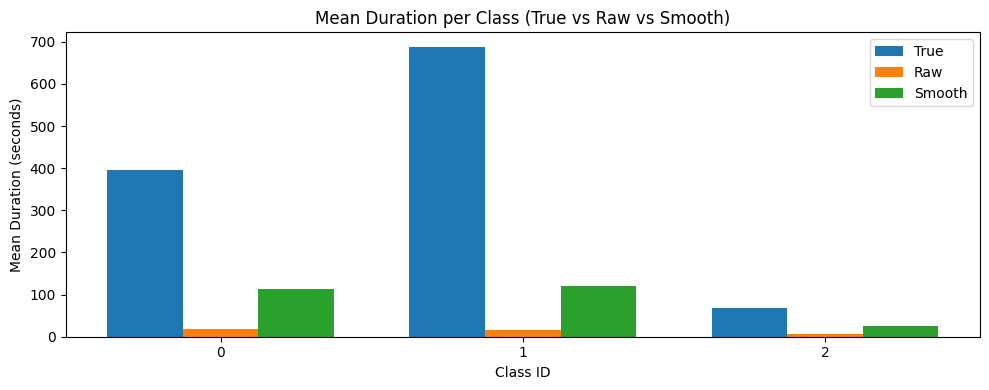

In [11]:
import numpy as np
from collections import defaultdict

def compute_mean_duration(y_seq, seconds_per_window):
    """
    y_seq: 時系列ラベル (list / np.array)
    seconds_per_window: ウィンドウ1個あたりの秒数
    """
    y_seq = np.asarray(y_seq)
    n = len(y_seq)

    durations = defaultdict(list)

    start = 0
    for i in range(1, n):
        if y_seq[i] != y_seq[i-1]:
            # 直前までの連続区間を確定
            cls = y_seq[i-1]
            length = i - start
            durations[cls].append(length * seconds_per_window)
            start = i

    # 最後の区間
    cls = y_seq[-1]
    length = n - start
    durations[cls].append(length * seconds_per_window)

    # 平均継続時間
    mean_durations = {}
    for cls, spans in durations.items():
        mean_durations[cls] = np.mean(spans)

    return mean_durations

seconds_per_window = 4   # 例: 8.533 秒

mean_true = compute_mean_duration(y_true, seconds_per_window)
mean_raw  = compute_mean_duration(y_pred, seconds_per_window)
mean_smooth = compute_mean_duration(y_pred_smooth, seconds_per_window)

print("Mean duration (true):", mean_true)
print("Mean duration (raw):", mean_raw)
print("Mean duration (smooth):", mean_smooth)

import pandas as pd

# クラス一覧（例: 0,1,2）
classes = sorted(set(list(mean_true.keys()) +
                     list(mean_raw.keys()) +
                     list(mean_smooth.keys())))

rows = []
for cls in classes:
    rows.append([
        cls,
        mean_true.get(cls, np.nan),
        mean_raw.get(cls, np.nan),
        mean_smooth.get(cls, np.nan),
    ])

df_duration = pd.DataFrame(
    rows,
    columns=["class", "true_mean_sec", "raw_mean_sec", "smooth_mean_sec"]
)

print(df_duration)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df_duration))
width = 0.25  # 棒の幅

plt.figure(figsize=(10,4))

plt.bar(x - width, df_duration["true_mean_sec"],   width, label="True")
plt.bar(x,         df_duration["raw_mean_sec"],    width, label="Raw")
plt.bar(x + width, df_duration["smooth_mean_sec"], width, label="Smooth")

plt.xticks(x, df_duration["class"])
plt.xlabel("Class ID")
plt.ylabel("Mean Duration (seconds)")
plt.title("Mean Duration per Class (True vs Raw vs Smooth)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
import os
import json
import numpy as np


# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=9):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1
    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)
        segment = y[l:r]
        out[i] = np.bincount(segment).argmax()

    return out


base_dir = "results_loso"

# === 対象となる T6〜T10 のフォルダ名 ===
target_prefix = ["T6_", "T7_", "T8_", "T9_", "T10_"]

# === seed0〜seed5 を処理 ===
for seed in range(6):
    seed_dir = os.path.join(base_dir, f"seed{seed}")
    if not os.path.exists(seed_dir):
        continue

    print(f"\n=== Processing {seed_dir} ===")

    # --- seed 内のディレクトリ一覧 ---
    for tdir in os.listdir(seed_dir):

        # T6〜T10 のフォルダだけ対象にする
        if not any(tdir.startswith(prefix) for prefix in target_prefix):
            continue

        full_src = os.path.join(seed_dir, tdir)
        if not os.path.isdir(full_src):
            continue

        # smooth フォルダ名
        smooth_dir = tdir + "_smooth"
        full_dst = os.path.join(seed_dir, smooth_dir)
        os.makedirs(full_dst, exist_ok=True)

        print(f"  Variant: {tdir} → {smooth_dir}")

        # JSON 一つずつ平滑化して保存
        for fname in os.listdir(full_src):

            if not fname.endswith(".json"):
                continue

            src_path = os.path.join(full_src, fname)
            dst_path = os.path.join(full_dst, fname)

            # --- 元 JSON 読み込み ---
            with open(src_path, "r") as fp:
                data = json.load(fp)

            y_pred = np.array(data["y_pred"])
            y_pred_smooth = smooth_majority(y_pred, k=5)

            # --- 置換して保存 ---
            data["y_pred"] = y_pred_smooth.tolist()

            with open(dst_path, "w") as fp:
                json.dump(data, fp, indent=2)

            print(f"    Saved {dst_path}")

print("\nDone.")



=== Processing results_loso/seed0 ===
  Variant: T6_noPT_uniform → T6_noPT_uniform_smooth
    Saved results_loso/seed0/T6_noPT_uniform_smooth/1.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/21.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/13.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/2.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/6.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/9.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/23.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/27.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/36.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/16.json
  Variant: T7_noPT_layerwise → T7_noPT_layerwise_smooth
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/1.json
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/21.json
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/13.json
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/2.json
    Saved r

In [2]:
import os
import json
import numpy as np


# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=9):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1
    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)
        segment = y[l:r]
        out[i] = np.bincount(segment).argmax()

    return out


base_dir = "results_loso"

# === 対象となる T6〜T10 のフォルダ名 ===
target_prefix = ["T6_", "T7_", "T8_", "T9_", "T10_"]

# === seed0〜seed5 を処理 ===
for seed in range(6):
    seed_dir = os.path.join(base_dir, f"seed{seed}")
    if not os.path.exists(seed_dir):
        print(f"\n=== Skipping {seed_dir} (not found) ===")
        continue

    print(f"\n=== Processing {seed_dir} ===")

    # --- seed 内の variant を走査 ---
    for tdir in os.listdir(seed_dir):

        # T6〜T10 のフォルダのみ対象
        if not any(tdir.startswith(prefix) for prefix in target_prefix):
            continue

        full_src = os.path.join(seed_dir, tdir)
        if not os.path.isdir(full_src):
            continue

        # === smooth 用ディレクトリを作成 ===
        smooth_dir = tdir + "_smooth"
        full_dst = os.path.join(seed_dir, smooth_dir)
        os.makedirs(full_dst, exist_ok=True)

        print(f"  Variant: {tdir} → {smooth_dir}")

        # === 各 session ディレクトリを処理 ===
        for sess in os.listdir(full_src):
            sess_src = os.path.join(full_src, sess)
            if not os.path.isdir(sess_src):
                continue

            sess_dst = os.path.join(full_dst, sess)
            os.makedirs(sess_dst, exist_ok=True)

            # === 各 JSON ===
            for fname in os.listdir(sess_src):
                if not fname.endswith(".json"):
                    continue

                src_path = os.path.join(sess_src, fname)
                dst_path = os.path.join(sess_dst, fname)

                # --- JSON 読み込み ---
                with open(src_path, "r") as fp:
                    data = json.load(fp)

                y_pred = np.array(data["y_pred"])
                y_pred_smooth = smooth_majority(y_pred, k=5)

                # --- 保存 ---
                data["y_pred"] = y_pred_smooth.tolist()

                with open(dst_path, "w") as fp:
                    json.dump(data, fp, indent=2)

                print(f"    Saved {dst_path}")

print("\nDone.")



=== Skipping results_loso/seed0 (not found) ===

=== Skipping results_loso/seed1 (not found) ===

=== Skipping results_loso/seed2 (not found) ===

=== Skipping results_loso/seed3 (not found) ===

=== Skipping results_loso/seed4 (not found) ===

=== Skipping results_loso/seed5 (not found) ===

Done.


In [30]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import re

def load_subject_f1(results_dir):
    f1_dict = {}

    for fname in sorted(os.listdir(results_dir)):
        if not fname.endswith(".json"):
            continue

        user = fname.replace(".json", "")

        # ===== 数字が含まれないファイルはスキップ =====
        m = re.search(r"\d+", user)
        if m is None:
            continue

        sid = "ID" + str(int(m.group()))

        with open(os.path.join(results_dir, fname)) as fp:
            res = json.load(fp)

        y_true = np.array(res["y_true"])
        y_pred = np.array(res["y_pred"])

        f1 = f1_score(y_true, y_pred, average="macro")
        f1_dict[sid] = f1

    return f1_dict

root = "results_loso/1212"

model_f1 = {}
for model in sorted(os.listdir(root)):
    model_dir = os.path.join(root, model)
    if not os.path.isdir(model_dir):
        continue

    model_f1[model] = load_subject_f1(model_dir)


In [26]:
os.listdir(root)

['T1_noPT_uniform',
 'T3_PT_frozen',
 'T4_PT_ft_uniform',
 'T5_PT_ft_layerwise',
 'T11_noPT_uniform',
 'T12_noPT_uniform']

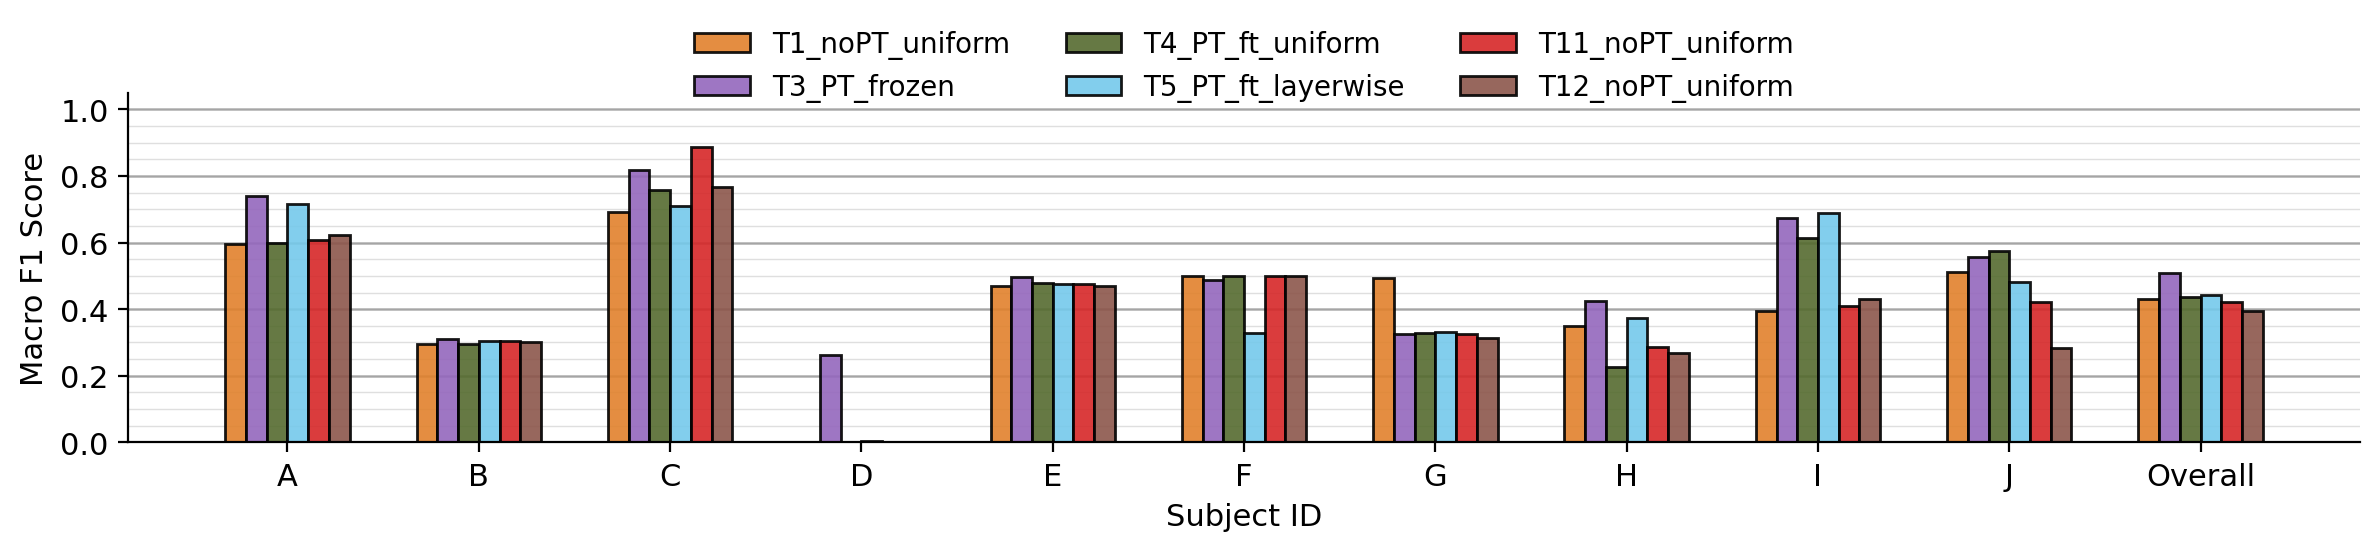

In [31]:
model_names = [
    "T1_noPT_uniform",
    "T3_PT_frozen",
    "T4_PT_ft_uniform",
    "T5_PT_ft_layerwise",
    "T11_noPT_uniform",
    "T12_noPT_uniform",
]

# model_names = [
# 'T1_noPT_uniform',
#  #'T2_noPT_layerwise',
#  'T3_PT_frozen',
#  #'T4_PT_ft_uniform',
#  #'T5_PT_ft_layerwise',
#  'T6_noPT_uniform',
#  #'T7_noPT_layerwise',
#  'T8_PT_frozen',
#  #'T9_PT_ft_uniform',
#  #'T10_PT_ft_layerwise',
# ]

name_list = {1: 'A', 36: 'B', 13: 'C', 21: 'D', 2: 'E',
             6: 'F', 23: 'G', 27: 'H', 9: 'I', 16: 'J'}

subject_ids = ["ID1", "ID36", "ID13", "ID21", "ID2",
               "ID6", "ID23", "ID27", "ID9", "ID16"]

x_labels = [name_list[int(s[2:])] for s in subject_ids]
x_labels.append("Overall")

colors = [
    "#E1812C", "#9467bd", "#556b2f",
    "#75c9eb", "#d62728", "#8c564b"
]

methods = [
    (name, model_f1[name], colors[i])
    for i, name in enumerate(model_names)
]

import numpy as np
import matplotlib.pyplot as plt

spacing = 1.2
x = np.arange(len(x_labels)) * spacing
width = 0.13

plt.figure(figsize=(12, 3), dpi=200)

for i, (label, f1_dict, color) in enumerate(methods):
    scores = [f1_dict[sid] for sid in subject_ids]
    scores.append(np.mean(scores))  # Overall

    offset = (i - (len(methods)-1)/2) * width
    plt.bar(x + offset, scores, width=width,
            label=label, color=color,
            edgecolor="black", alpha=0.9)

# grid
for y in np.arange(0, 1.01, 0.2):
    plt.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
for y in np.arange(0, 1.01, 0.05):
    plt.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

plt.xticks(x, x_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim([-1, x[-1] + 1])
plt.ylim(0, 1.05)
plt.xlabel("Subject ID", fontsize=11)
plt.ylabel("Macro F1 Score", fontsize=11)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25),
           ncol=3, frameon=False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# UBI

In [2]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import re

def load_subject_f1(results_dir):
    """
    return:
        {
          "ID1": {"macro": 0.73, "weighted": 0.81},
          "ID36": {...},
          ...
        }
    """
    f1_dict = {}

    for fname in sorted(os.listdir(results_dir)):
        if not fname.endswith(".json"):
            continue

        user = fname.replace(".json", "")

        # 数字が含まれないものはスキップ
        m = re.search(r"\d+", user)
        if m is None:
            continue

        sid = "ID" + str(int(m.group()))

        with open(os.path.join(results_dir, fname)) as fp:
            res = json.load(fp)

        y_true = np.array(res["y_true"])
        y_pred = np.array(res["y_pred"])

        f1_dict[sid] = {
            "macro": f1_score(y_true, y_pred, average="macro"),
            "weighted": f1_score(y_true, y_pred, average="weighted"),
        }

    return f1_dict


In [3]:
root = "results_loso/1213"

model_f1 = {}
for model in sorted(os.listdir(root)):
    model_dir = os.path.join(root, model)
    if not os.path.isdir(model_dir):
        continue

    model_f1[model] = load_subject_f1(model_dir)


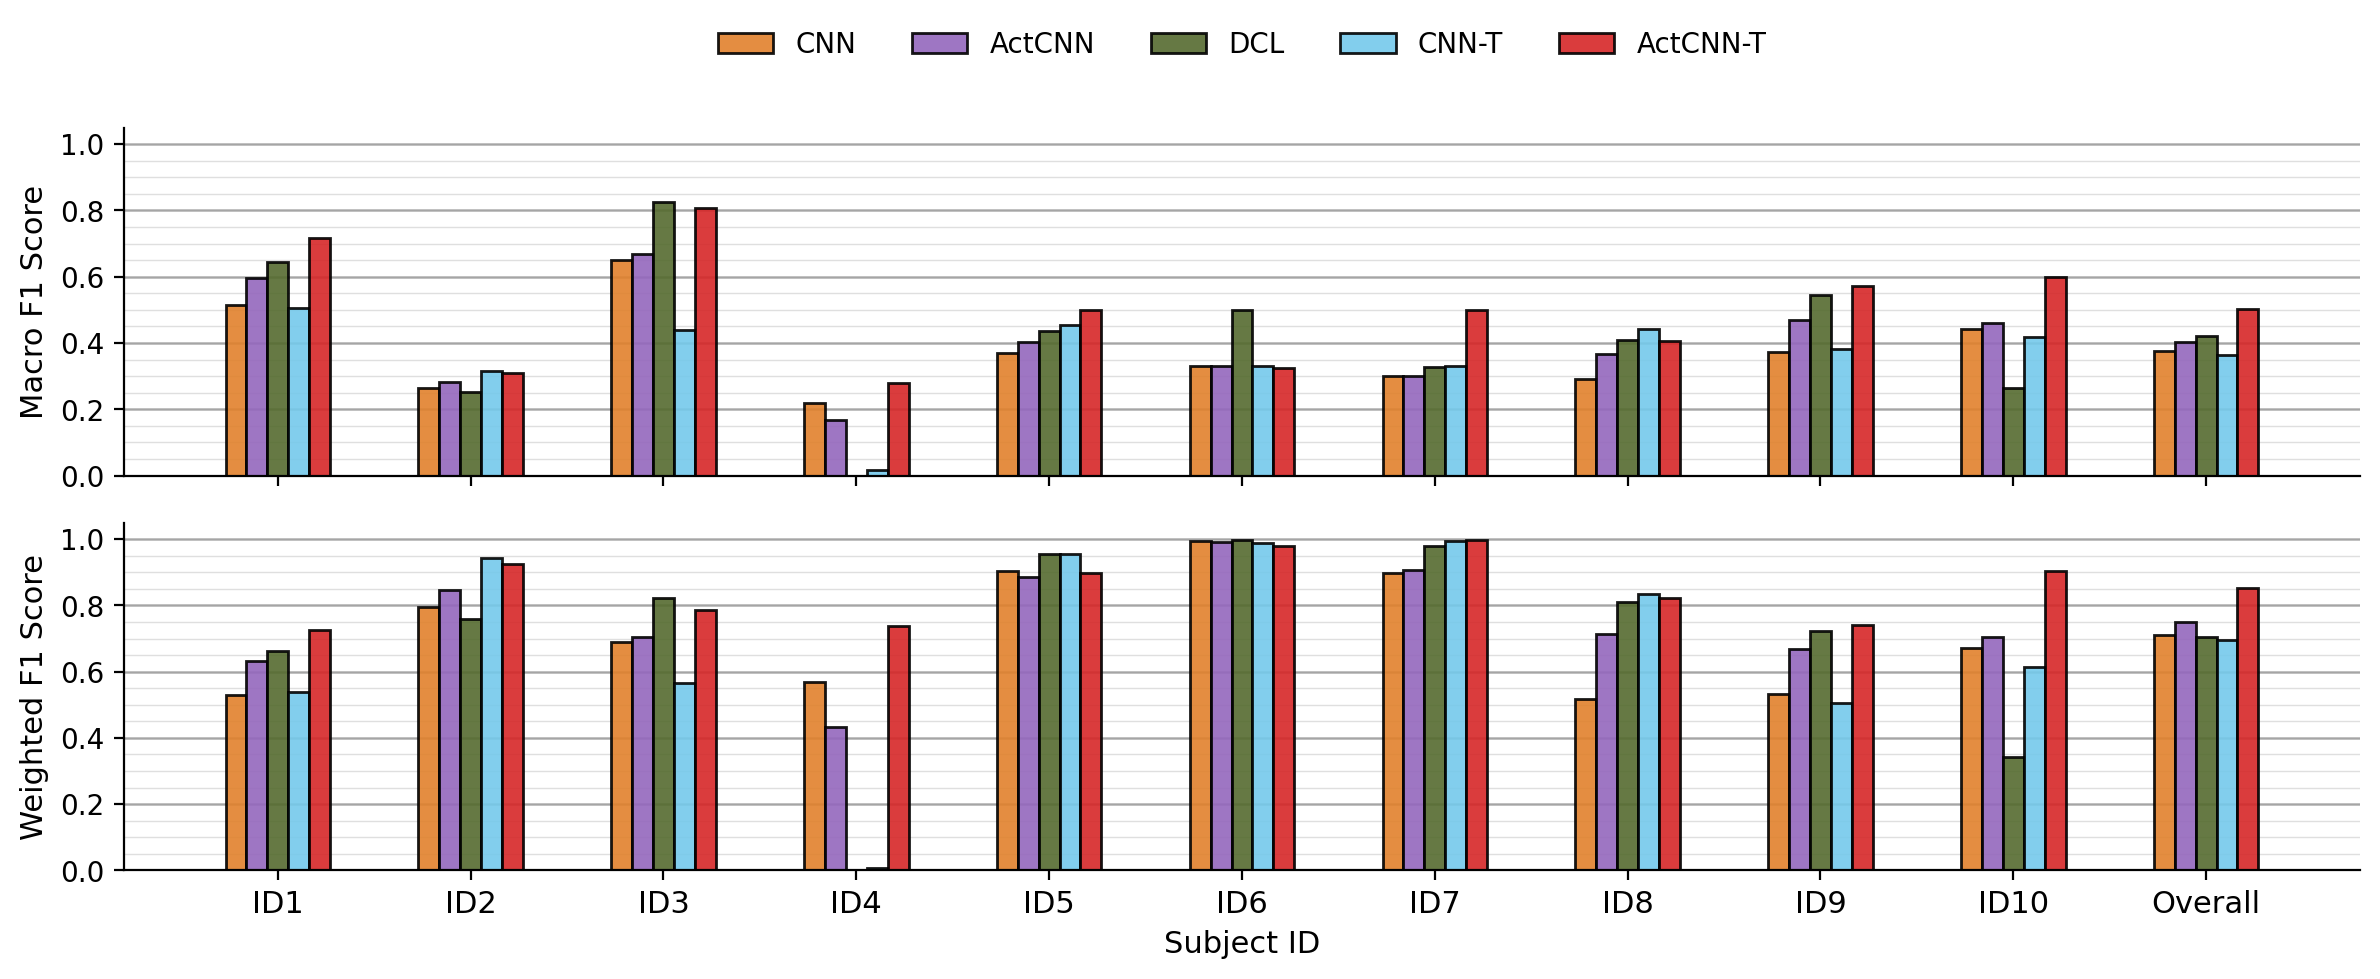

In [4]:
import numpy as np
import matplotlib.pyplot as plt


model_names = [
    "CNN",
    "ActCNN",
    "DCL",
    "CNN-T",
    "ActCNN-T",
]
colors = [
    "#E1812C", "#9467bd", "#556b2f",
    "#75c9eb", "#d62728", "#8c564b"
]

# name_list = {1: 'A', 36: 'B', 13: 'C', 21: 'D', 2: 'E',
#              6: 'F', 23: 'G', 27: 'H', 9: 'I', 16: 'J'}

name_list = {1: 'ID1', 36: 'ID2', 13: 'ID3', 21: 'ID4', 2: 'ID5',
             6: 'ID6', 23: 'ID7', 27: 'ID8', 9: 'ID9', 16: 'ID10'}

subject_ids = ["ID1", "ID36", "ID13", "ID21", "ID2",
               "ID6", "ID23", "ID27", "ID9", "ID16"]

x_labels = [name_list[int(s[2:])] for s in subject_ids] + ["Overall"]

spacing = 1.2
x = np.arange(len(x_labels)) * spacing
width = 0.13

fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=200, sharex=True)

for ax, metric, title in zip(
    axes,
    ["macro", "weighted"],
    ["Macro F1 Score", "Weighted F1 Score"]
):
    for i, model in enumerate(model_names):
        f1_dict = model_f1[model]

        scores = [f1_dict[sid][metric] for sid in subject_ids]
        scores.append(np.mean(scores))  # Overall

        offset = (i - (len(model_names)-1)/2) * width
        ax.bar(x + offset, scores, width=width,
               color=colors[i], edgecolor="black",
               alpha=0.9, label=model if metric == "macro" else None)

    # grid
    for y in np.arange(0, 1.01, 0.2):
        ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
    for y in np.arange(0, 1.01, 0.05):
        ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel(title, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# x-axis
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(x_labels, fontsize=11)
axes[-1].set_xlabel("Subject ID", fontsize=11)

# legend（上だけ）
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.35),
               ncol=5, frameon=False)

plt.tight_layout()
plt.show()


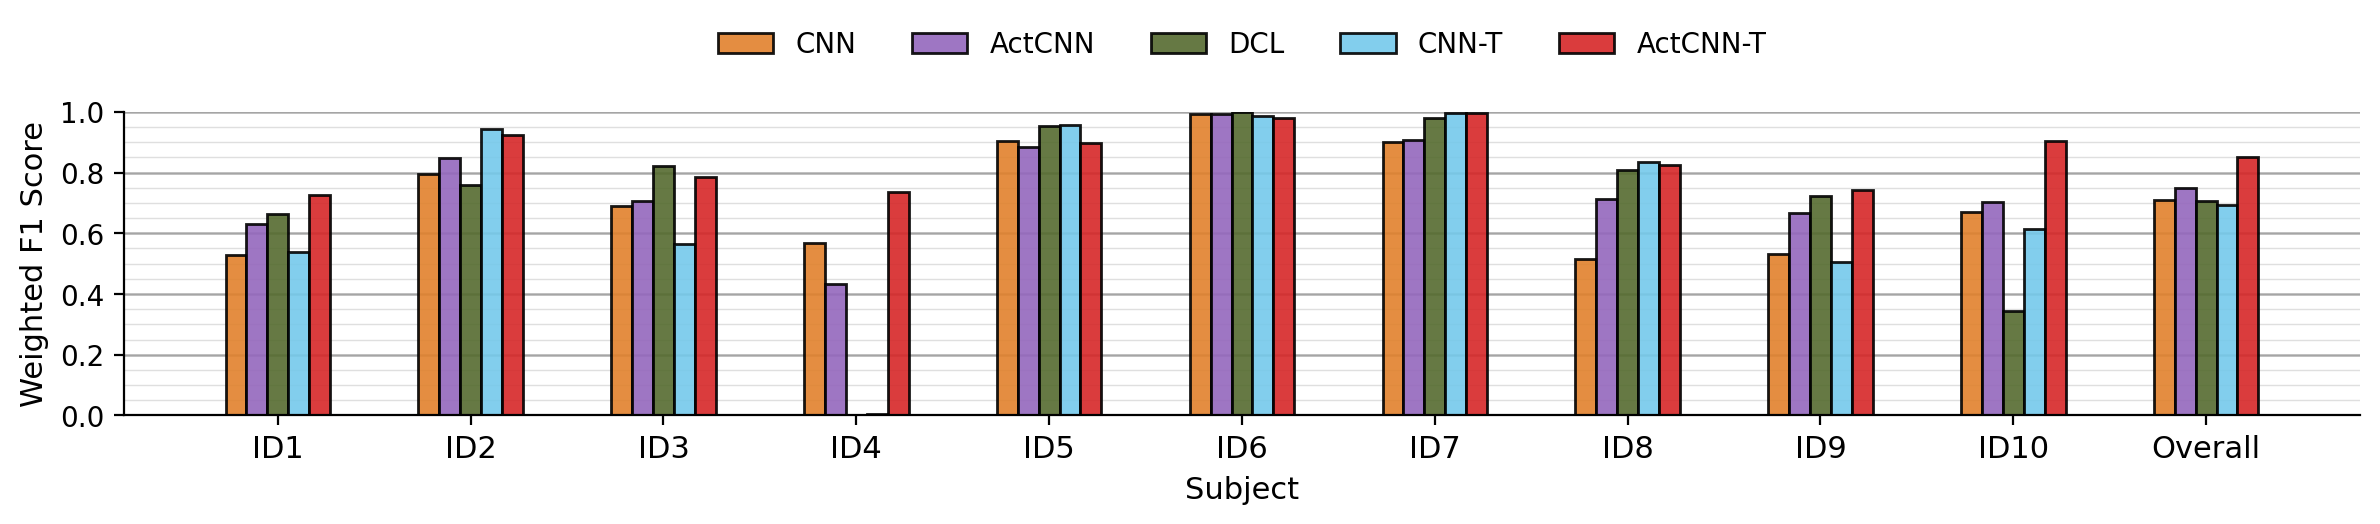

In [5]:
spacing = 1.2
x = np.arange(len(x_labels)) * spacing
width = 0.13

fig, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=200)

for i, model in enumerate(model_names):
    f1_dict = model_f1[model]

    scores = [f1_dict[sid]["weighted"] for sid in subject_ids]
    scores.append(np.mean(scores))  # Overall
    

    offset = (i - (len(model_names) - 1) / 2) * width
    ax.bar(
        x + offset, scores, width=width,
        color=colors[i], edgecolor="black",
        alpha=0.9, label=model
    )

# grid
for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
for y in np.arange(0, 1.01, 0.05):
    ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Weighted F1 Score", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_xlabel("Subject", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=len(model_names),
    frameon=False
)

plt.tight_layout()
plt.show()


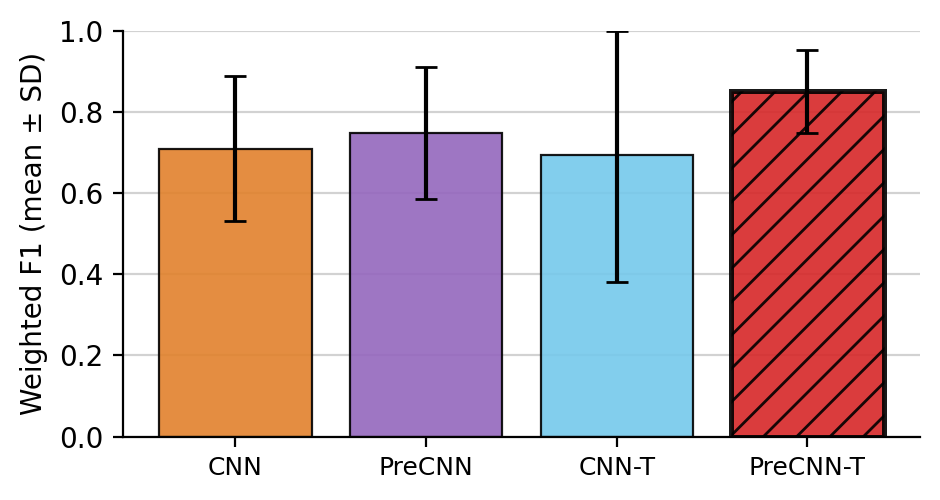

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 設定（就活向け：Overallのみ・コンパクト） ---
use_metric = "weighted"        # "weighted" or "macro"
figsize = (4.8, 2.6)           # 右半分想定
dpi = 200

# 表示名（短め）
pretty = {
    "CNN": "CNN",
    "ActCNN": "PreCNN",
    "CNN-T": "CNN-T",
    "ActCNN-T": "PreCNN-T",
}

# 4本の順番（あなたの内部名に合わせて変更OK）
plot_models = ["CNN", "ActCNN", "CNN-T", "ActCNN-T"]
proposed_key = "ActCNN-T"      # 提案手法の内部名

# 色（元の colors があるならそのまま流用）
# 無ければ matplotlib のデフォルトでもOK
use_colors = True

# --- 集計：被験者ごとのF1から mean±SD（0-1にクリップ） ---
labels, means, yerr_low, yerr_high, cols = [], [], [], [], []
for i, mname in enumerate(plot_models):
    f1_dict = model_f1[mname]
    per_sub = np.array([f1_dict[sid][use_metric] for sid in subject_ids], dtype=float)

    mean = float(per_sub.mean())
    sd = float(per_sub.std(ddof=1)) if len(per_sub) >= 2 else 0.0

    low = max(0.0, mean - sd)
    high = min(1.0, mean + sd)

    labels.append(pretty.get(mname, mname))
    means.append(mean)
    yerr_low.append(mean - low)
    yerr_high.append(high - mean)

    if use_colors:
        cols.append(colors[model_names.index(mname)] if mname in model_names else None)
    else:
        cols.append(None)

x = np.arange(len(labels))

# --- 描画 ---
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

bars = ax.bar(
    x, means,
    yerr=[yerr_low, yerr_high],   # 非対称エラーバー
    capsize=4,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    color=cols if any(c is not None for c in cols) else None,
)

# 提案手法だけ強調（枠太め＋ハッチ）
for b, mname in zip(bars, plot_models):
    if mname == proposed_key:
        b.set_linewidth(1.8)
        b.set_hatch("//")

# grid（薄め）
for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.8, alpha=0.35, zorder=0)

ax.set_ylim(0, 1.0)
ax.set_ylabel(f"{use_metric.capitalize()} F1 (mean ± SD)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [11]:
import numpy as np

use_metric = "weighted"
plot_models = ["CNN", "ActCNN", "CNN-T", "ActCNN-T"]  # あなたの内部名
pretty = {
    "CNN": "CNN",
    "ActCNN": "CNN+pretrain",
    "CNN-T": "CNN+Transformer",
    "ActCNN-T": "Proposed(pretrain+Trans.)",
}

def summarize_mean_sd(model_key):
    f1_dict = model_f1[model_key]
    per_sub = np.array([f1_dict[sid][use_metric] for sid in subject_ids], dtype=float)

    mean = float(per_sub.mean())
    sd = float(per_sub.std(ddof=1)) if len(per_sub) >= 2 else 0.0
    hi = mean + sd
    lo = mean - sd

    # クリップ版（表示用）
    lo_c = max(0.0, lo)
    hi_c = min(1.0, hi)

    return {
        "n": len(per_sub),
        "mean": mean,
        "sd": sd,
        "mean-sd": lo,
        "mean+sd": hi,
        "clipped_low": lo_c,
        "clipped_high": hi_c,
        "num_subjects_gt_0p95": int((per_sub > 0.95).sum()),
        "min": float(per_sub.min()),
        "max": float(per_sub.max()),
    }

for m in plot_models:
    s = summarize_mean_sd(m)
    name = pretty.get(m, m)
    print(f"\n[{name}] n={s['n']}")
    print(f"  mean={s['mean']:.3f}, sd={s['sd']:.3f}")
    print(f"  mean±sd = [{s['mean-sd']:.3f}, {s['mean+sd']:.3f}]  (clipped: [{s['clipped_low']:.3f}, {s['clipped_high']:.3f}])")
    print(f"  min-max = [{s['min']:.3f}, {s['max']:.3f}]  | subjects>0.95: {s['num_subjects_gt_0p95']}")



[CNN] n=10
  mean=0.710, sd=0.178
  mean±sd = [0.532, 0.888]  (clipped: [0.532, 0.888])
  min-max = [0.516, 0.994]  | subjects>0.95: 1

[CNN+pretrain] n=10
  mean=0.749, sd=0.162
  mean±sd = [0.587, 0.911]  (clipped: [0.587, 0.911])
  min-max = [0.434, 0.991]  | subjects>0.95: 1

[CNN+Transformer] n=10
  mean=0.694, sd=0.313
  mean±sd = [0.381, 1.008]  (clipped: [0.381, 1.000])
  min-max = [0.006, 0.995]  | subjects>0.95: 3

[Proposed(pretrain+Trans.)] n=10
  mean=0.852, sd=0.102
  mean±sd = [0.750, 0.954]  (clipped: [0.750, 0.954])
  min-max = [0.726, 0.998]  | subjects>0.95: 2


In [13]:
def extract_common_subjects(model_f1):
    subjects = None
    for d in model_f1.values():
        s = set(d.keys())
        subjects = s if subjects is None else subjects & s
    return sorted(subjects)

print("--Overall Macro F1--")
#  print overall score
for model in model_names:
    f1_dict = model_f1[model]
    scores = [f1_dict[sid]["macro"] for sid in extract_common_subjects({k: model_f1[k] for k in model_names})]
    overall = np.mean(scores)
    print(f"{model}: F1 = {overall:.4f}")

print("--Overall Weighted F1--")

for model in model_names:
    f1_dict = model_f1[model]
    scores = [f1_dict[sid]["weighted"] for sid in extract_common_subjects({k: model_f1[k] for k in model_names})]
    overall = np.mean(scores)
    print(f"{model}: F1 = {overall:.4f}")


--Overall Macro F1--
CNN: F1 = 0.3754
ActCNN: F1 = 0.4045
DCL: F1 = 0.4200
CNN-T: F1 = 0.3630
ActCNN-T: F1 = 0.5017
--Overall Weighted F1--
CNN: F1 = 0.7101
ActCNN: F1 = 0.7486
DCL: F1 = 0.7052
CNN-T: F1 = 0.6943
ActCNN-T: F1 = 0.8516


In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np
import os
import json
import re

def load_confusion_all_subjects(results_dir, labels=None):
    """
    return:
        conf_mat (ndarray): shape = (C, C)
    """
    y_true_all = []
    y_pred_all = []

    for fname in sorted(os.listdir(results_dir)):
        if not fname.endswith(".json"):
            continue

        # 数字を含まないファイルはスキップ（安全）
        if re.search(r"\d+", fname) is None:
            continue

        with open(os.path.join(results_dir, fname)) as fp:
            res = json.load(fp)

        y_true_all.extend(res["y_true"])
        y_pred_all.extend(res["y_pred"])

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm = confusion_matrix(
        y_true_all,
        y_pred_all,
        labels=labels
    )
    return cm


In [31]:
from sklearn.metrics import confusion_matrix
import numpy as np
import os
import json
import re


def load_confusion_all_subjects_swap(results_dir, labels=None):
    """
    return:
        conf_mat (ndarray): shape = (C, C)
        ※ y_true / y_pred のラベル 1 と 2 を入れ替えた状態で集計
    """
    y_true_all = []
    y_pred_all = []

    for fname in sorted(os.listdir(results_dir)):
        if not fname.endswith(".json"):
            continue

        # 数字を含まないファイルはスキップ（安全）
        if re.search(r"\d+", fname) is None:
            continue

        with open(os.path.join(results_dir, fname)) as fp:
            res = json.load(fp)

        y_true = np.array(res["y_true"])
        y_pred = np.array(res["y_pred"])

        # ===== ラベル 1 ↔ 2 を入れ替え =====
        y_true_swapped = y_true.copy()
        y_pred_swapped = y_pred.copy()

        y_true_swapped[y_true == 1] = 2
        y_true_swapped[y_true == 2] = 1

        y_pred_swapped[y_pred == 1] = 2
        y_pred_swapped[y_pred == 2] = 1
        # ==================================

        y_true_all.extend(y_true_swapped)
        y_pred_all.extend(y_pred_swapped)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm = confusion_matrix(
        y_true_all,
        y_pred_all,
        labels=labels
    )
    return cm


In [32]:
root = "results_loso/1213"

# model_names = [
#     "CNN",
#     "CNN(Pretrained)",
#     "DCL",
#     "ActCNN-T",
#     "ActCNN-T(Pretrained)",
# ]

model_names = [
    "CNN",
    "ActCNN",
    "DCL",
    "CNN-T",
    "ActCNN-T",
]


In [33]:

labels = ['Inspect', 'Sort', 'Transport'] 

conf_mats = {}

for model in model_names:
    model_dir = os.path.join(root, model)
    if not os.path.isdir(model_dir):
        print(f"[WARN] not found: {model}")
        continue

    conf_mats[model] = load_confusion_all_subjects_swap(model_dir)


Plotting confusion matrix for CNN...


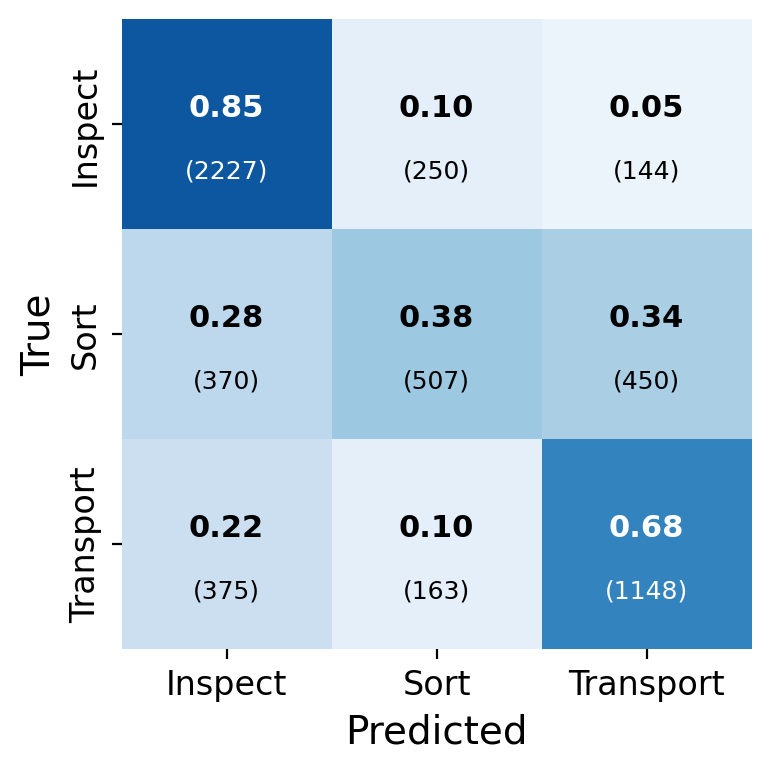

Plotting confusion matrix for ActCNN...


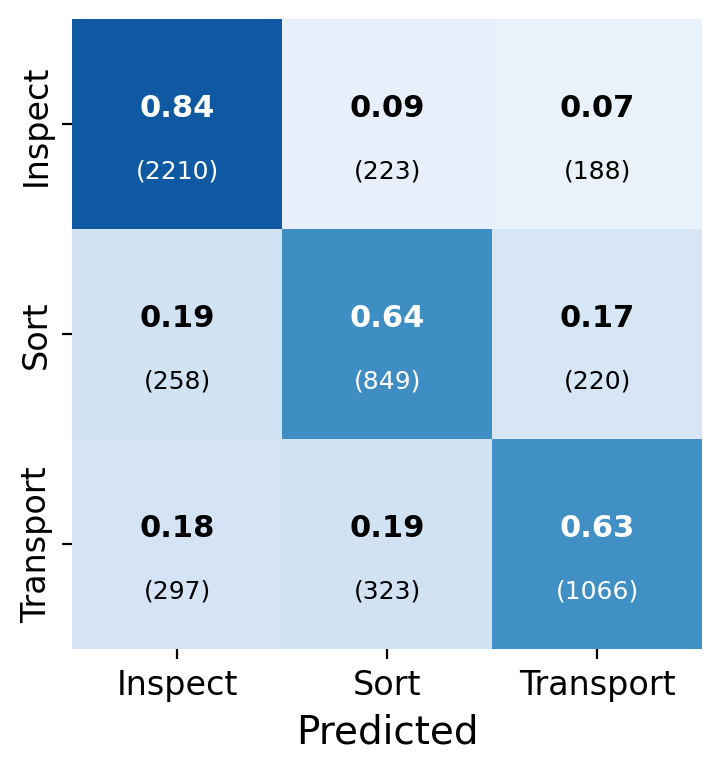

Plotting confusion matrix for DCL...


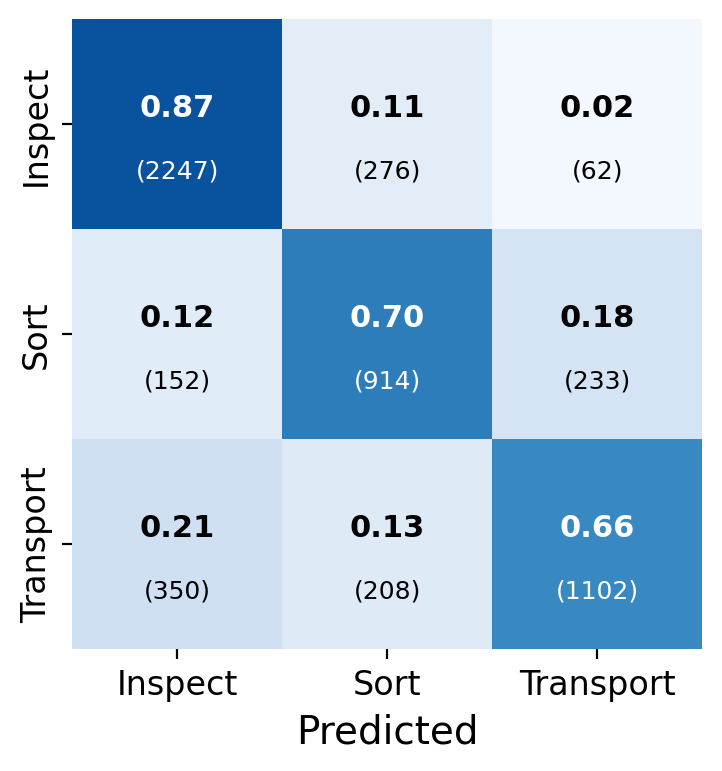

Plotting confusion matrix for CNN-T...


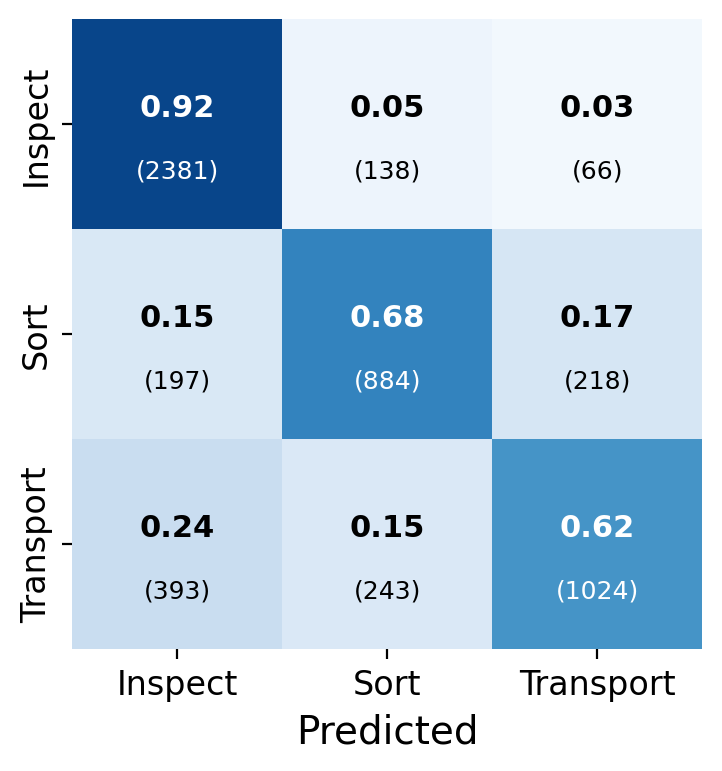

Plotting confusion matrix for ActCNN-T...


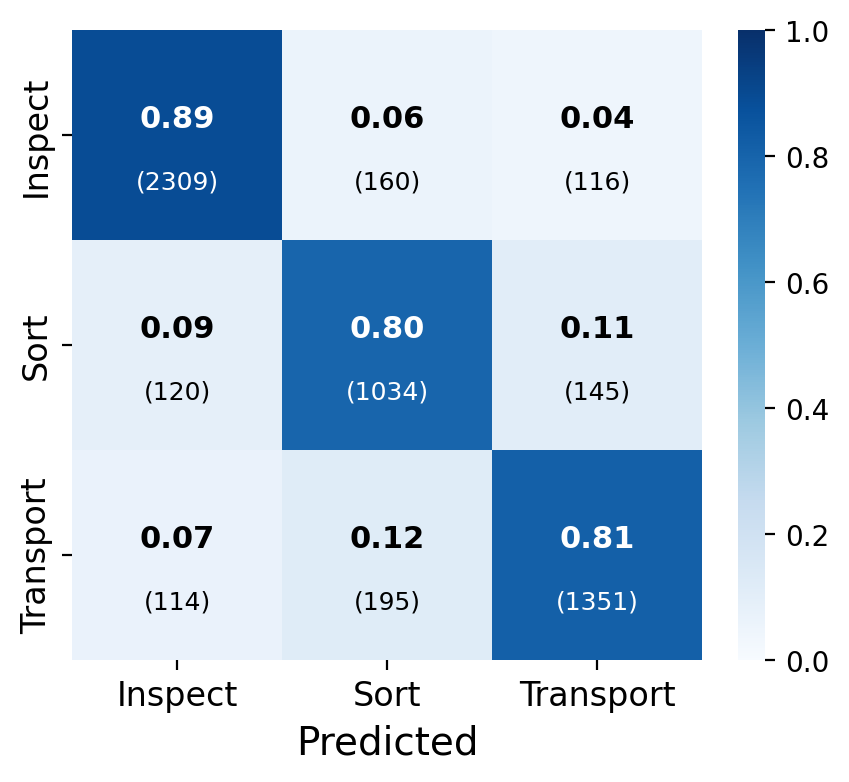

In [34]:
cm_counts_all = []
cm_normalized_all = []

for model in model_names:
    cm = conf_mats[model].astype(float)

    cm_counts_all.append(cm.copy())

    # 行正規化（True label 基準）
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_normalized_all.append(cm_norm)


def get_luminance(rgb):
    return 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

#cmap
cmap = sns.color_palette("Blues", as_cmap=True)

# === 共通サイズ設定 ===
figsize = (4.5, 4.5)
dpi = 200

num_models = len(model_names)
num_classes = len(labels)

for i, model in enumerate(model_names):
    print(f"Plotting confusion matrix for {model}...")
    fig = plt.figure(figsize=figsize, dpi=dpi)

    # メイン軸（余白をやや詰める）
    ax = fig.add_axes([0.12, 0.12, 0.70, 0.70])

    # カラーバーは最後のみ
    cax = fig.add_axes([0.86, 0.12, 0.03, 0.70]) if i == num_models - 1 else None

    sns.heatmap(
        cm_normalized_all[i],
        annot=False,
        cmap=cmap,
        vmin=0.0, vmax=1.0,
        square=True,
        #linewidths=0.5,
        #linecolor="gray",
        cbar=(cax is not None),
        ax=ax,
        cbar_ax=cax
    )

    # === Ticks ===
    ax.set_xticks(np.arange(num_classes) + 0.5)
    ax.set_yticks(np.arange(num_classes) + 0.5)

    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)

    # 軸ラベルは最小限
    ax.set_xlabel("Predicted", fontsize=14)
    if i == 0:
        ax.set_ylabel("True", fontsize=14)
    else:
        ax.set_ylabel("")

    # === Cell text (value + count) ===
    facecolors = ax.collections[0].get_facecolors()

    for r in range(num_classes):
        for c in range(num_classes):
            rgb = facecolors[r * num_classes + c][:3]
            text_color = "white" if get_luminance(rgb) < 0.6 else "black"

            # 正規化値
            ax.text(
                c + 0.5, r + 0.42,
                f"{cm_normalized_all[i][r, c]:.2f}",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=text_color
            )

            # カウント
            ax.text(
                c + 0.5, r + 0.72,
                f"({int(cm_counts_all[i][r, c])})",
                ha="center", va="center",
                fontsize=9,
                color=text_color
            )

    # === Title ===
    #ax.set_title(model, fontsize=12, pad=6)

    # === Save / Show ===
    # fig.savefig(f"{output_dir}/{file_names[i]}", bbox_inches="tight")
    plt.show(block=False)
    plt.pause(0.3)
    plt.close(fig)


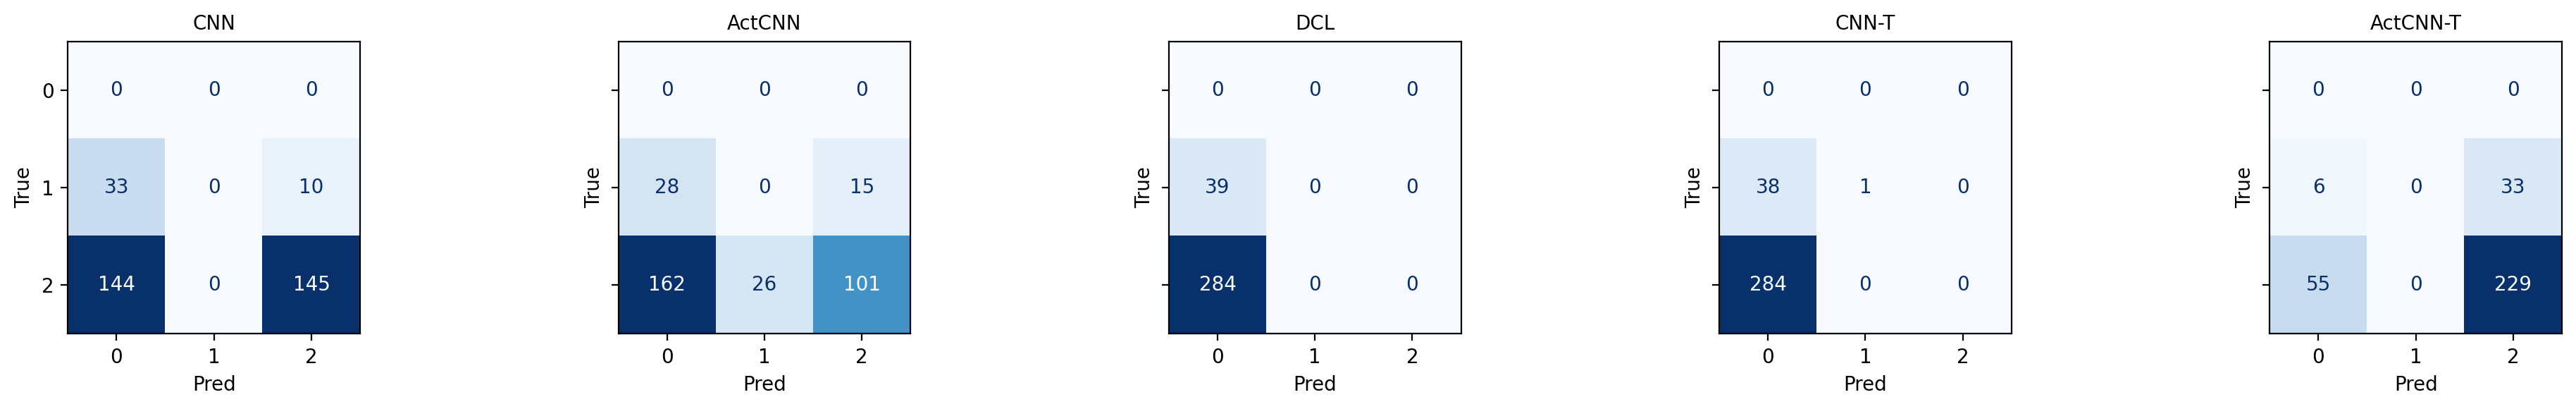

In [36]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===== 設定 =====
target_subject = "21"   # ← ID21 に対応する実ID
target_session = "S0100"
target_seed = "seed0"

# model_names = [
#     "CNN",
#     "CNN(Pretrained)",
#     "DCL",
#     "ActCNN-Transformer",
#     "ActCNN-Transformer(Pretrained)",
# ]


model_names = [
    "CNN",
    "ActCNN",
    "DCL",
    "CNN-T",
    "ActCNN-T",
]

root = "results_loso/1213"

# ===== plot =====
fig, axes = plt.subplots(
    1, len(model_names),
    figsize=(4 * len(model_names), 3),
    dpi=200,
    sharey=True
)

if len(model_names) == 1:
    axes = [axes]

for ax, model in zip(axes, model_names):
    json_path = f"/home/kisho_ucl/kisho_ws/har_warehouse/trusco_exp/results_loso/1213/{model}/{target_subject}.json"

    with open(json_path, "r") as f:
        r = json.load(f)

    y_true = np.array(r["y_true"])
    y_pred = np.array(r["y_pred"])

    # ===== ラベル 1 ↔ 2 を入れ替え =====
    y_true_swapped = y_true.copy()
    y_pred_swapped = y_pred.copy()

    y_true_swapped[y_true == 1] = 2
    y_true_swapped[y_true == 2] = 1

    y_pred_swapped[y_pred == 1] = 2
    y_pred_swapped[y_pred == 2] = 1
    # ==================================

    cm = confusion_matrix(y_true_swapped, y_pred_swapped)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=".0f"
    )

    ax.set_title(model, fontsize=10)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()
